# Function selection

**Recipe 27** · Level 3 (Intermediate) · Decision type: `Choice`

Select a function from a preapproved catalog for a request while Python validates supplied arguments before simulated execution.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)
- S06: [TypeSafe AI: Cookbooks](https://docs.typesafe.ai/cookbooks)

## What you will build

A small function-calling gate. Jev reads a user's request and picks exactly one of six preapproved functions, or `no_function` when none of them fits. Python never lets that choice alone trigger anything: a confidence gate screens every option, `no_function` included, and a function cleared at the gate still has to pass a second, deterministic stage -- Python checking the arguments the request supplies against that function's own schema -- before anything is simulated as executed. By the end you will have seen the typed answer itself, the two-stage rule that acts on it, the simulated action log and review queue it fills, and an evaluation at the level of the whole task, not only of the raw choice.

This notebook uses 40 made-up requests (19 `validation`, 19 `test`, 2 `demo`): clean matches, requests that match nothing, requests that match a function but supply arguments that function's own schema rejects, requests ambiguous between two functions, and (on `test`) one request Jev confidently answers with the wrong function -- one whose own schema happens to accept the arguments supplied, so stage two cannot catch the mistake either.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays stored answers offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls and changes nothing else. The header states which mode ran, and every number below carries that mode with it.

In [1]:
from collections import Counter

from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_outcomes,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.simulation import ActionLog, ReviewQueue
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# scored excludes the two demo examples: they carry no gold label, so no metric below is
# about them (see "gold label" under Evaluation).
scored = [e for e in examples if e.split not in ("train", "demo")]
# Every request's extracted arguments, computed once and reused everywhere stage two needs
# them: the tested extractor in helpers.py, never a hand-written dict.
arguments_by_id = {e.id: helpers.extract_arguments(e.fields["request"]) for e in examples}

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: a number from the validation split is a selection step, not a
# reported result. This label does not depend on the run mode, unlike `check` above: even a
# recorded or live run must not print a bare validation number. A synthetic or scripted run
# prints both labels on a validation number (`{selection}{check}`): it is still a pipeline
# check too.
selection = " (a selection step, not a reported result)"


def decide(example):
    """Answer one request, using this example's own per-item shuffled option order."""
    order = helpers.option_order_for(example.id)
    questions = helpers.build_questions(order)
    return backend.decide(helpers.build_state(example.fields), questions)["function"]


run_header(27, "Function selection", backend=backend, n_examples=len(scored))

Recipe 27: Function selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The [state](../../docs/glossary.md#state) is everything Jev sees, and Python builds it: just the request's own text, verbatim. Python separately runs a tested extractor, `extract_arguments`, over that same text to recover the `"Arguments: ..."` trailer a request supplies. Jev is never asked about the arguments themselves, only which function (if any) fits the request, so the extracted arguments never appear in the state -- they feed stage two instead, further down.

In [2]:
demo = {e.id: e for e in examples if e.split == "demo"}
request = demo["demo-02"]
print("Python has:")
print(request.fields["request"])
state = helpers.build_state(request.fields)
print("Jev sees:")
print(state)
print("Python also extracts, for stage two only (never sent to Jev):")
print(helpers.extract_arguments(request.fields["request"]))

Python has:
File a ticket about the broken login page.
Arguments: title=Broken login page
Jev sees:
{'request': 'File a ticket about the broken login page.\nArguments: title=Broken login page'}
Python also extracts, for stage two only (never sent to Jev):
{'title': 'Broken login page'}


## The questions

One [question](../../docs/glossary.md#question), asked once per request: which catalog function, if any, should handle it? A [Choice](../../docs/glossary.md#choice) fits because the options are mutually exclusive and Jev must commit to one. Python builds the option list from the preapproved catalog in `helpers.FUNCTIONS` -- six fabricated functions, each with a one-line description and an argument schema -- plus the fallback `no_function`: seven options for every request, so the single-option case ([backends.md](../../docs/backends.md#single-option-choice)) never comes up here. The order the seven options are listed in is not the catalog's own order: it is shuffled per request with `jev_cookbook.fixtures.stable_shuffle`, seeded from this recipe's slug and the request's own id, so a rule that always answered "the first option shown" cannot score well merely because some function happens to be listed first most of the time ([fixtures.md](../../docs/fixtures.md#per-item-option-order)).

In [3]:
print("The catalog:")
for name, spec in helpers.FUNCTIONS.items():
    arguments = ", ".join(
        f"{arg}{'*' if arg_spec['required'] else ''}" for arg, arg_spec in spec["schema"].items()
    )
    print(f"  {name:18s} {spec['description']}")
    print(f"  {'':18s} arguments ('*' = required): {arguments}")
print(f"  {helpers.NO_FUNCTION:18s} none of the catalog functions should be called")

order = helpers.option_order_for(request.id)
questions = helpers.build_questions(order)
function = questions["function"]
print()
print(function.instructions)
print("options, in the order this particular request happens to show them:")
for name in function.criteria:
    print(f"  {name}")

The catalog:
  send_email         Send an email message to one recipient.
                     arguments ('*' = required): to*, subject*, body*, priority
  schedule_meeting   Schedule a calendar meeting with one or more attendees.
                     arguments ('*' = required): title*, attendees*, duration_minutes*, date*
  create_ticket      File a new ticket in the support tracking system.
                     arguments ('*' = required): title*, priority*, assignee
  set_reminder       Create a reminder that fires at a future date.
                     arguments ('*' = required): message*, remind_at*, channel
  update_record      Update one field of an existing customer record.
                     arguments ('*' = required): record_id*, field*, value*
  lookup_contact     Search the contact directory for matching people.
                     arguments ('*' = required): query*, max_results
  no_function        none of the catalog functions should be called

A user sent the request b

### Where the gold function lands in the shuffled order

If the gold function always happened to land first in its own shuffled order, a rule that ignored Jev entirely and always picked whatever is shown first would score just as well, for the wrong reason (`docs/fixtures.md`, "Per-item option order"). The table below counts, over every one of the 38 scored requests, which position (1 = first shown) the gold function actually occupies.

In [4]:
positions = Counter()
for example in scored:
    order = helpers.option_order_for(example.id)
    positions[order.index(labels[example.id]) + 1] += 1
print("gold-function position in the shown order, across all 38 scored requests:")
for position in range(1, len(helpers.OPTION_NAMES) + 1):
    print(f"  position {position}: {positions.get(position, 0)}")

gold-function position in the shown order, across all 38 scored requests:
  position 1: 5
  position 2: 5
  position 3: 7
  position 4: 5
  position 5: 5
  position 6: 6
  position 7: 5


## One answer up close

Before any aggregate, look at one typed answer. A `Choice` answer holds the chosen option, a probability for every option, and a [confidence](../../docs/glossary.md#confidence): the top [probability](../../docs/glossary.md#probabilities) rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`, so it is 0 when the top option has no more than an even share of the seven and 1 when one option has all the probability. The provenance line says where the answer came from.

In [5]:
state = helpers.build_state(request.fields)
order = helpers.option_order_for(request.id)
questions = helpers.build_questions(order)
answer = backend.decide(state, questions)["function"]
show_answer(answer)

Choice: create_ticket (confidence 0.80)
  create_ticket     0.83  #################
  send_email        0.03  #
  schedule_meeting  0.03  #
  set_reminder      0.03  #
  update_record     0.03  #
  lookup_contact    0.03  #
  no_function       0.03  #
Provenance: synthetic


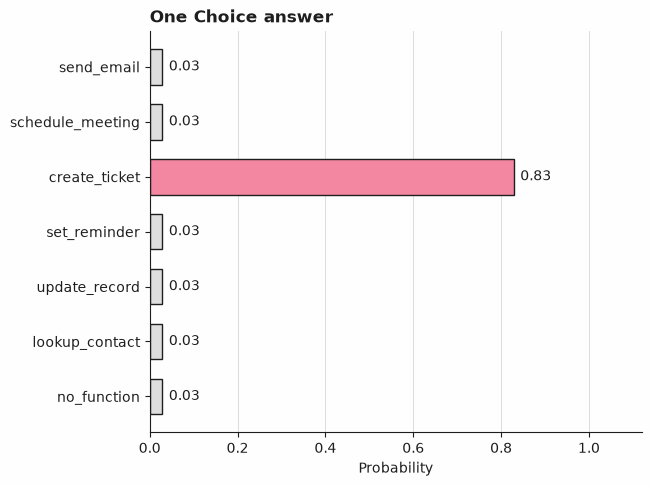

In [6]:
plot_answer_probabilities(answer, title="One Choice answer")

## Python's part

Jev supplies the function choice; everything after that is code. Every option goes through the same confidence gate first, `no_function` included: an answer below the threshold is sent to a simulated [review](../../docs/glossary.md#review) queue with the reason `"confidence below the threshold"`, whatever option it names. A real function that clears the gate still has to pass stage two: Python's own argument validator, `helpers.validate_arguments`, checks the arguments `extract_arguments` recovered from the request against that function's own schema -- deterministically, with no confidence of its own -- before anything is simulated as executed. Invalid arguments send the request to review too, naming the first violation; only a function that clears both the gate and the validator is recorded in a simulated action log, which never actually sends, schedules, files, reminds, updates or looks anything up.

### The simulated side effects

`no_function` is the fallback this use case names, and CONTRIBUTING.md section 4's three-part test is worth working through for it directly, because it genuinely passes every part:

| | `no_function` |
| - | - |
| (a) complete answer, not a deferral? | yes -- "call nothing" is a real, final judgment about this request, not "ask a person to decide the same question again" |
| (b) records no action? | yes -- choosing it never reaches the action-recording branch of `helpers.resolve` at all |
| (c) wrong leaves nothing beyond the missed item? | yes -- a wrongly-chosen `no_function` leaves exactly one request's intended action undone, the same thing sending it to review would also have left pending |

Passing all three makes `no_function` eligible to be delivered as a final result at any confidence, with no further gate -- CONTRIBUTING.md section 4's exemption. This rule does not take it: `helpers.resolve` gates `no_function` through the same confidence check as every other option, no differently (see the code cell below, and `tests/test_helpers.py::test_resolve_sends_a_low_confidence_answer_to_review_whatever_it_names`). Gating a qualifying fallback anyway is explicitly compliant, and it keeps this recipe to one review reason for every low-confidence answer rather than a second, `no_function`-specific rule to maintain alongside it. Because nothing here is exempted, this recipe's own `evaluate_outcomes` numbers in the Evaluation section already are the gated numbers; there is no separate counterfactual to print.

A function's invalid-argument rejection is never a candidate for this same exemption: it is not a fallback *option* Jev chooses, it is Python's own stage-two check overriding a *different* option -- the function Jev actually named -- so the three-part test, which is about a fallback option's own confidence, does not apply to it the way it applies to `no_function`.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

demo_actions, demo_queue = ActionLog(), ReviewQueue()
for shown_id in ("demo-01", "demo-02"):
    shown = demo[shown_id]
    shown_answer = decide(shown)
    resolution = helpers.resolve(
        shown_id,
        shown_answer,
        arguments_by_id[shown_id],
        threshold,
        actions=demo_actions,
        queue=demo_queue,
    )
    print(
        f"{shown_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {resolution.outcome} ({resolution.reason})"
    )

chosen threshold, frozen from here on: 0.6000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
demo-01: schedule_meeting at confidence 0.85 -> executed (confident match, valid arguments)
demo-02: create_ticket at confidence 0.80 -> review (missing required argument: priority)


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section applies the whole composed rule -- the gate, then stage two's argument check -- to every request in `validation` and in `test`, and reports at both levels this use case asks for: per-question selection [accuracy](../../docs/glossary.md#accuracy) (does the raw `Choice` answer name the gold function, before any gate or validation), and task level (does the pipeline's final outcome -- and, for an executed request, which function it executed -- match what a flawless rule would have done with the same extracted arguments). The two can disagree: a confidently wrong selection can still execute, if the wrongly-named function's own schema happens to accept the arguments this request supplies, and only the task-level numbers below catch that. Selective [coverage, accuracy and risk](../../docs/glossary.md#coverage) come from the rule's own accept/review decisions (`jev_cookbook.evaluation.evaluate_outcomes`), never from reapplying the confidence gate alone: an invalid-argument rejection is unconditional on confidence, so this rule's review branch is more than the gate, and `evaluate_selective` would disagree with it about which requests were answered (see "Selective prediction" in [evaluation.md](../../docs/evaluation.md)). The use case's second named metric, the invalid-argument rejection rate, is reported for the hard case this recipe's fixtures name explicitly: requests whose *gold* function's own extracted arguments are invalid for it.

In [8]:
def resolve_split(split_examples, answers):
    actions, queue = ActionLog(), ReviewQueue()
    resolutions = [
        helpers.resolve(e.id, a, arguments_by_id[e.id], threshold, actions=actions, queue=queue)
        for e, a in zip(split_examples, answers, strict=True)
    ]
    return resolutions, actions, queue


def show_log(name, actions, queue):
    print(f"{name} action log: {len(actions)} entries{check}")
    for kind, n in sorted(Counter(e["kind"] for e in actions.to_dicts()).items()):
        print(f"  {kind:18s} {n}")
    print(f"{name} review queue: {len(queue)} entries{check}")
    for reason, n in sorted(Counter(i["reason"] for i in queue.to_dicts()).items()):
        print(f"  {reason:48s} {n}")


val_resolutions, val_actions, val_queue = resolve_split(val_examples, val_answers)
val_gold_by_id = {e.id: g for e, g in zip(val_examples, val_gold, strict=True)}
val_accepted, val_correct2 = helpers.accepted_and_correct(
    val_resolutions, val_gold_by_id, arguments_by_id
)
val_outcomes = evaluate_outcomes(val_accepted, val_correct2)
val_hard_cases = helpers.invalid_argument_hard_cases(val_gold_by_id, arguments_by_id)
val_rejection_rate = helpers.invalid_argument_rejection_rate(
    {r.item_id: r for r in val_resolutions}, val_hard_cases
)

print(f"validation, {len(val_examples)} examples{selection}{check}")
print(
    f"selection accuracy (raw choice vs. gold): {accuracy(val_gold, val_answers):.4f}"
    f"{selection}{check}"
)
print(
    f"task-level answered (coverage): {val_outcomes.n_answered} of {val_outcomes.n_total} "
    f"(coverage {val_outcomes.coverage:.4f}){selection}{check}"
)
print(f"task-level accuracy among those answered: {val_outcomes.accuracy:.4f}{selection}{check}")
print(f"task-level risk among those answered: {val_outcomes.risk:.4f}{selection}{check}")
print(
    f"invalid-argument hard cases on validation: {len(val_hard_cases)} of "
    f"{len(val_examples)} ({', '.join(val_hard_cases)}){selection}{check}"
)
print(f"invalid-argument rejection rate: {val_rejection_rate:.4f}{selection}{check}")
show_log("validation", val_actions, val_queue)

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
selection accuracy (raw choice vs. gold): 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
task-level answered (coverage): 13 of 19 (coverage 0.6842) (a selection step, not a reported result) (a pipeline check, not a Jev result)
task-level accuracy among those answered: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
task-level risk among those answered: 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
invalid-argument hard cases on validation: 3 of 19 (v09, v10, v11) (a selection step, not a reported result) (a pipeline check, not a Jev result)
invalid-argument rejection rate: 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
validation action log: 11 entries (a pipeline check, not a Jev result)
  create_ticket      2
  lookup_contact    

In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_resolutions, test_actions, test_queue = resolve_split(test_examples, test_answers)
test_gold_by_id = {e.id: g for e, g in zip(test_examples, test_gold, strict=True)}
test_accepted, test_correct2 = helpers.accepted_and_correct(
    test_resolutions, test_gold_by_id, arguments_by_id
)
test_outcomes = evaluate_outcomes(test_accepted, test_correct2)
test_hard_cases = helpers.invalid_argument_hard_cases(test_gold_by_id, arguments_by_id)
test_rejection_rate = helpers.invalid_argument_rejection_rate(
    {r.item_id: r for r in test_resolutions}, test_hard_cases
)

print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"selection accuracy (raw choice vs. gold): {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"task-level answered (coverage): {test_outcomes.n_answered} of {test_outcomes.n_total} "
    f"(coverage {test_outcomes.coverage:.4f}){check}"
)
print(f"task-level accuracy among those answered: {test_outcomes.accuracy:.4f}{check}")
print(f"task-level risk among those answered: {test_outcomes.risk:.4f}{check}")
print(
    f"invalid-argument hard cases on test: {len(test_hard_cases)} of {len(test_examples)} "
    f"({', '.join(test_hard_cases)}){check}"
)
print(f"invalid-argument rejection rate: {test_rejection_rate:.4f}{check}")
show_log("test", test_actions, test_queue)

test, 19 examples, threshold 0.6000 frozen (a pipeline check, not a Jev result)
selection accuracy (raw choice vs. gold): 0.9474 (a pipeline check, not a Jev result)
task-level answered (coverage): 14 of 19 (coverage 0.7368) (a pipeline check, not a Jev result)
task-level accuracy among those answered: 0.9286 (a pipeline check, not a Jev result)
task-level risk among those answered: 0.0714 (a pipeline check, not a Jev result)
invalid-argument hard cases on test: 3 of 19 (t09, t10, t11) (a pipeline check, not a Jev result)
invalid-argument rejection rate: 1.0000 (a pipeline check, not a Jev result)
test action log: 12 entries (a pipeline check, not a Jev result)
  create_ticket      2
  lookup_contact     1
  schedule_meeting   2
  send_email         3
  set_reminder       2
  update_record      2
test review queue: 5 entries (a pipeline check, not a Jev result)
  confidence below the threshold                   2
  missing required argument: remind_at             1
  value outside the 

Test confusion matrix, gold rows by predicted columns (a pipeline check, not a Jev result):
  predicted ->                 send_email  schedule_meeting     create_ticket      set_reminder     update_record    lookup_contact       no_function (a pipeline check, not a Jev result)
  gold send_email                       3                 0                 0                 0                 0                 0                 0 (a pipeline check, not a Jev result)
  gold schedule_meeting                 0                 2                 0                 0                 0                 0                 0 (a pipeline check, not a Jev result)
  gold create_ticket                    0                 0                 3                 0                 0                 0                 0 (a pipeline check, not a Jev result)
  gold set_reminder                     0                 0                 0                 4                 0                 0                 0 (a pipelin

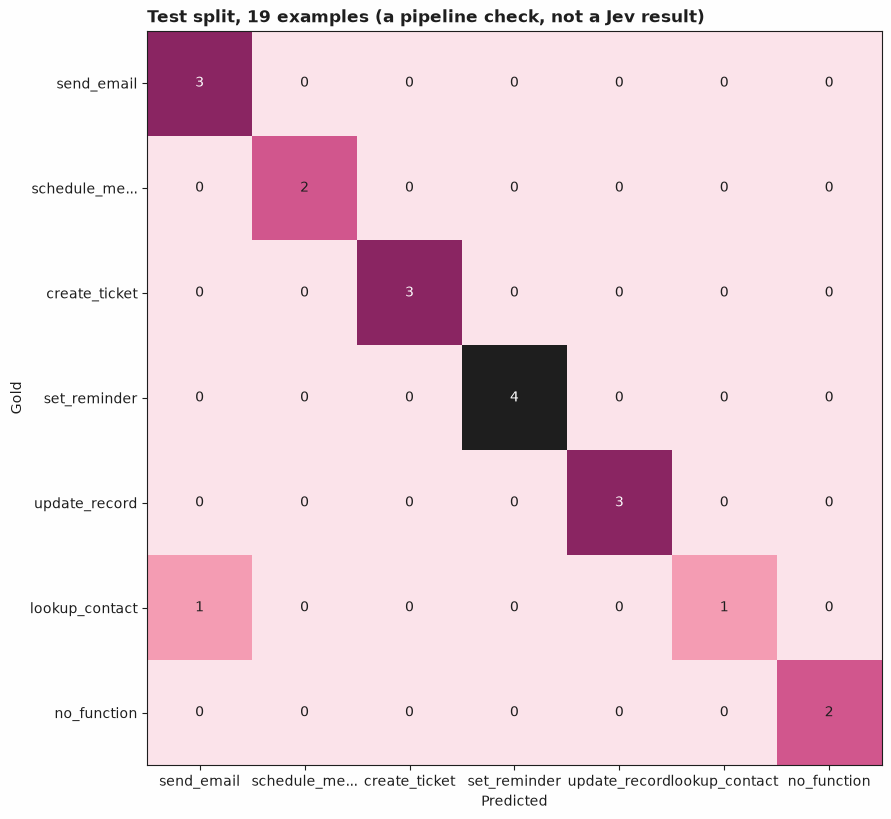

In [10]:
matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTION_NAMES))
WIDTH = max(len(label) for label in matrix.labels)
print(f"Test confusion matrix, gold rows by predicted columns{check}:")
header = "  ".join(f"{label:>{WIDTH}s}" for label in matrix.labels)
print(f"  {'predicted ->':<{5 + WIDTH}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{WIDTH}d}" for count in row)
    print(f"  gold {gold_label:<{WIDTH}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

In [11]:
print("Test requests the pipeline answered (not sent to review) but got wrong:")
for example, answer, resolution, answered, correct in zip(
    test_examples, test_answers, test_resolutions, test_accepted, test_correct2, strict=True
):
    if not (answered and not correct):
        # Excludes every request sent to review (low confidence, or an invalid-argument
        # rejection): correctly deferring is not a task-level mistake, whatever a flawless
        # rule's own outcome for it would have been.
        continue
    gold_function = test_gold_by_id[example.id]
    expected_outcome, expected_choice = helpers.gold_outcome(
        gold_function, arguments_by_id[example.id]
    )
    print(
        f"  {example.id}: gold {gold_function} (a flawless rule: {expected_outcome}/"
        f"{expected_choice}); Jev named {answer.choice} at confidence {answer.confidence:.2f} "
        f"-> {resolution.outcome}"
    )

Test requests the pipeline answered (not sent to review) but got wrong:
  t14: gold lookup_contact (a flawless rule: executed/lookup_contact); Jev named send_email at confidence 0.85 -> executed


The cell above is the one request where this recipe's two kinds of evaluation genuinely disagree. The raw choice is confidently wrong, and because the wrongly-named function's own schema happens to accept the arguments this request supplies, stage two's argument check cannot catch it either -- it was never asked to validate the gold function, only the one Jev actually named. Selection accuracy alone, and even the invalid-argument rejection rate above (which only ever looks at requests whose *gold* function's arguments are invalid), both read this request as fine; only the task-level accounting counts it as the pipeline's one `test` mistake. The fixtures include it on purpose, and a recipe's evaluation should find it rather than average it away.

## What was and was not measured

What this run can say about Jev depends on its mode, which the cell below states from `backend.mode`: a synthetic or scripted run is a pipeline check only, on the fixture sample it ran against; a recorded or live run states the model the API returned and when, for exactly the examples it covers. Nothing here says anything about Jev's quality, speed or cost unless that cell reports a recorded or live run. `N` below counts only the examples that carry a gold label, so it excludes the two `demo` examples shown earlier.

In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples{check}")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.
N: 19 validation and 19 test examples (a pipeline check, not a Jev result)


## Next steps

- Edit one function's schema in `helpers.py` (drop a required argument, say) and run `pytest recipes/27-function-selection` or this notebook: the stored replay keys still match the question, because a function's schema is Python-only and never part of what Jev is asked -- but a request that used to be an invalid-argument hard case may now validate cleanly, or vice versa.
- Add a request to `ROWS` in `build_fixtures.py` whose arguments supply every value a *different* catalog function also accepts, store a confident wrong answer for it (above the frozen gate), run `python build_fixtures.py`, and see whether it slips past stage two the same way `t14` does.
- Neighbouring recipes with the same catalog `Choice` decision shape: [`04-support-ticket-routing`](../04-support-ticket-routing/) (routing to a fixed set of service queues), [`08-faq-selection`](../08-faq-selection/) (selecting from a fixed set of candidate answers) and [`19-ci-failure-classification`](../19-ci-failure-classification/) (one outcome from a fixed catalog, with its own confidence-gated action log and review queue).

A neighbour link above is a folder link, `../NN-slug/`: `tools/render_catalog.py` builds the root README's catalog table from bare recipe titles with no per-row anchor, so a recipe cannot reliably link to another recipe's row there instead. Link only a neighbour whose `notebook.ipynb` is already committed on `main`: a folder link to a recipe that is not yet published would 404 on GitHub, and a forward link like that is not allowed ([docs/recipe-template.md](../../docs/recipe-template.md)).